# PhyloP conservation EDA

UCSC hg38 **phyloP100way** at expert-reviewed ClinVar SNVs (reference base, not allele-specific).

Unlike gnomAD AF, this **is** a model feature (`phylop_100way` in `FEATURE_COLUMNS`).

PhyloP is sometimes ACMG **PP3/BP4**, as supporting/moderate computational evidence, not stand-alone like **BA1**. Expect some label leakage, milder than population frequency.

```
python src/ingest_phylop.py    # data/processed/phylop_clean.parquet
```

Joined at train/inference time by `add_phylop_features()`.


In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()
project_root = Path(os.environ["PROJECT_ROOT"])
sys.path.insert(0, str(project_root / "src"))

from features import FEATURE_COLUMNS, add_gnomad_features, prepare_modeling_frame, prepare_inference_frame

PHYLOP_CLEAN = project_root / "data/processed/phylop_clean.parquet"
POSITION_MATCHED = project_root / "data/processed/clinvar_uniprot_position_matched.parquet"
POSITION_MATCHED_VUS = project_root / "data/processed/clinvar_uniprot_position_matched_vus.parquet"
JOINED_GNOMAD = project_root / "data/processed/clinvar_uniprot_gnomad_position_matched.parquet"

sns.set_theme(style="whitegrid")


## 1. In `FEATURE_COLUMNS` (unlike gnomAD)

Positive phyloP → slower than neutral evolution (conserved). Negative → faster (accelerated). Trees split on the raw score; sklearn median-imputes the rare missing values.


In [2]:
print("phylop_100way in FEATURE_COLUMNS?", "phylop_100way" in FEATURE_COLUMNS)
print("any gnomAD name in FEATURE_COLUMNS?", any("gnomad" in c.lower() for c in FEATURE_COLUMNS))
print()
print("FEATURE_COLUMNS:")
for c in FEATURE_COLUMNS:
    print(" ", c)


phylop_100way in FEATURE_COLUMNS? True
any gnomAD name in FEATURE_COLUMNS? False

FEATURE_COLUMNS:
  protein_position
  relative_protein_position
  distance_to_closest_feature
  phylop_100way
  has_protein_position
  in_domain
  in_region
  in_zinc_finger
  in_active_site
  in_binding_site
  in_disulfide
  in_mod_res
  in_functional_site
  in_any_feature
  closest_feature_type
  ReferenceAlleleVCF
  AlternateAlleleVCF


## 2. Coverage

One row per unique ClinVar `chrom-pos` (P/B + VUS). phyloP100way is nuclear; mito and a few assembly gaps stay missing.


In [3]:
phy = pd.read_parquet(PHYLOP_CLEAN)
print(phy.shape)
print("found:", int(phy.found.sum()), f"({phy.found.mean():.1%})")
print("missing:")
print(phy.loc[~phy.found, ["chrom", "pos", "ucsc_chrom"]].to_string(index=False))
print()
print("phyloP among found sites:")
print(phy.loc[phy.found, "phylop_100way"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_string())


(13696, 5)
found: 13695 (100.0%)
missing:
chrom      pos ucsc_chrom
   13 32341669      chr13

phyloP among found sites:
count    13695.000000
mean         3.456105
std          3.680219
min        -20.000000
10%         -0.476624
25%          0.260717
50%          2.597960
75%          7.235940
90%          8.890000
max         10.003000


## 3. Score vs ClinVar label

Expert panels can use conservation under PP3/BP4, so a split is expected. It should **not** look like BA1 (common AF → 100% benign).


In [4]:
model = prepare_modeling_frame(pd.read_parquet(POSITION_MATCHED))
print("Modeling rows:", len(model))
print("phylop NA:", int(model.phylop_100way.isna().sum()))
print()
by = model.groupby("label").agg(
    n=("VariationID", "size"),
    n_missing=("phylop_100way", lambda s: int(s.isna().sum())),
    median=("phylop_100way", "median"),
    mean=("phylop_100way", "mean"),
    p10=("phylop_100way", lambda s: s.quantile(0.1)),
    p90=("phylop_100way", lambda s: s.quantile(0.9)),
)
print(by.round(3).to_string())


Modeling rows: 11563
phylop NA: 1

               n  n_missing  median   mean    p10    p90
label                                                   
benign      5211          1   0.229  0.756 -1.274  3.873
pathogenic  6352          0   5.938  5.307  0.402  9.424


/tmp/ipykernel_14124/2810654633.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


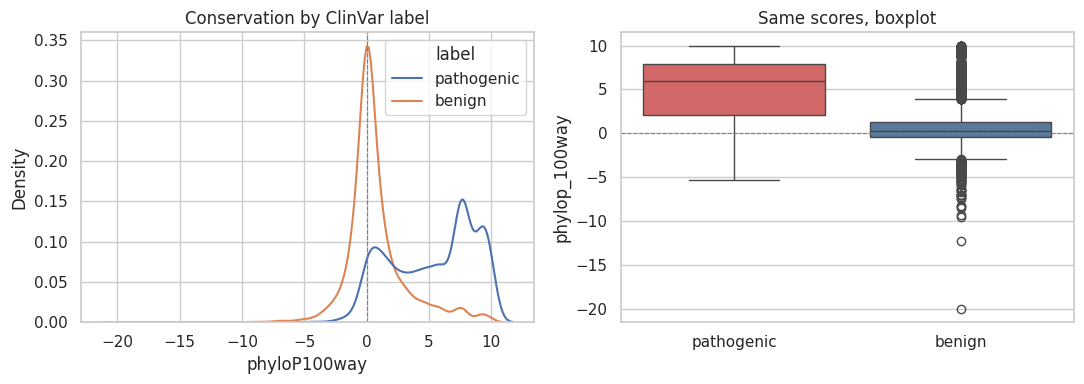

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.kdeplot(
    data=model.dropna(subset=["phylop_100way"]),
    x="phylop_100way", hue="label", common_norm=False, ax=axes[0],
)
axes[0].axvline(0, color="grey", lw=0.8, ls="--")
axes[0].set_xlabel("phyloP100way")
axes[0].set_title("Conservation by ClinVar label")

sns.boxplot(
    data=model.dropna(subset=["phylop_100way"]),
    x="label", y="phylop_100way", ax=axes[1],
    palette={"benign": "#4c78a8", "pathogenic": "#e45756"},
)
axes[1].axhline(0, color="grey", lw=0.8, ls="--")
axes[1].set_xlabel("")
axes[1].set_title("Same scores, boxplot")
plt.tight_layout()
plt.show()


## 4. Not BA1-strong: overlap stays large

A conserved site can be benign; an accelerated site can be pathogenic. PP3 is supporting/moderate, not stand-alone.


label                    benign  pathogenic  pct_pathogenic
phylop_bin                                                 
accelerated (<0)           2080         340            14.0
weak (0–2)                 2157        1189            35.5
moderate (2–4)              477         770            61.7
conserved (4–6)             238         924            79.5
strongly conserved (≥6)     258        3129            92.4


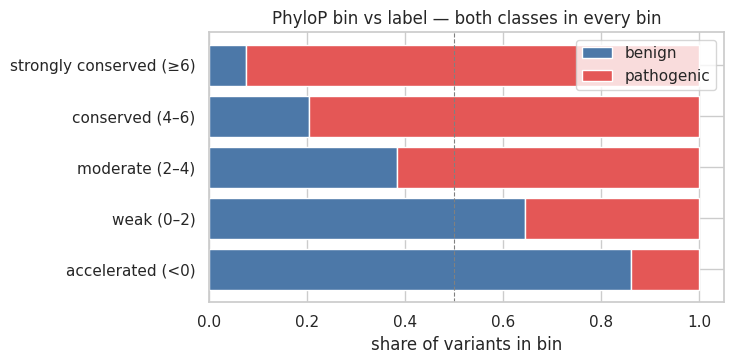

In [6]:
bins = [-20, 0, 2, 4, 6, 11]
labels = ["accelerated (<0)", "weak (0–2)", "moderate (2–4)", "conserved (4–6)", "strongly conserved (≥6)"]
plot = model.dropna(subset=["phylop_100way"]).copy()
plot["phylop_bin"] = pd.cut(plot["phylop_100way"], bins=bins, labels=labels, right=False)
ct = pd.crosstab(plot["phylop_bin"], plot["label"])
ct["pct_pathogenic"] = (ct["pathogenic"] / ct.sum(axis=1) * 100).round(1)
print(ct.to_string())

fig, ax = plt.subplots(figsize=(7.5, 3.8))
frac = pd.crosstab(plot["phylop_bin"], plot["label"], normalize="index")
frac.plot(kind="barh", stacked=True, ax=ax, color=["#4c78a8", "#e45756"], width=0.8)
ax.set_xlabel("share of variants in bin")
ax.set_ylabel("")
ax.set_title("PhyloP bin vs label — both classes in every bin")
ax.legend(title="")
ax.axvline(0.5, color="grey", lw=0.8, ls="--")
plt.tight_layout()
plt.show()


## 5. Absence from gnomAD is not conservation

Same discussion as `gnomad_eda.ipynb` §6: never seen in ~800k people ≠ conserved across species. Pathogenic variants are more often absent *and* more conserved; those are correlated, not the same measurement.


median phyloP by label × in_gnomad:
in_gnomad   absent  present
label                      
benign        0.22     0.23
pathogenic    5.95     5.93


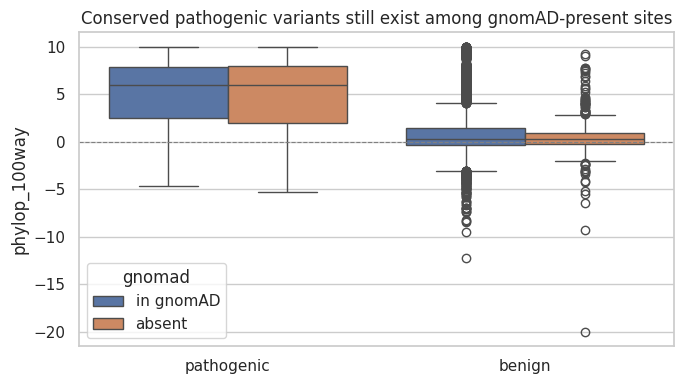

In [7]:
joined = add_gnomad_features(prepare_modeling_frame(pd.read_parquet(JOINED_GNOMAD)))
print("median phyloP by label × in_gnomad:")
print(
    joined.groupby(["label", "in_gnomad"])["phylop_100way"]
    .median()
    .unstack()
    .rename(columns={False: "absent", True: "present"})
    .round(2)
    .to_string()
)

fig, ax = plt.subplots(figsize=(7, 4))
tmp = joined.dropna(subset=["phylop_100way"]).assign(
    gnomad=lambda d: np.where(d.in_gnomad, "in gnomAD", "absent")
)
sns.boxplot(data=tmp, x="label", y="phylop_100way", hue="gnomad", ax=ax)
ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.set_xlabel("")
ax.set_title("Conserved pathogenic variants still exist among gnomAD-present sites")
plt.tight_layout()
plt.show()


## 6. Not the same as UniProt `in_domain`

Domain membership is protein annotation. PhyloP is nucleotide constraint. A domain can be tolerant; a conserved base can sit outside a curated domain.


median phyloP by label × in_domain:
in_domain   outside domain  in domain
label                                
benign                0.19       1.05
pathogenic            5.31       7.39


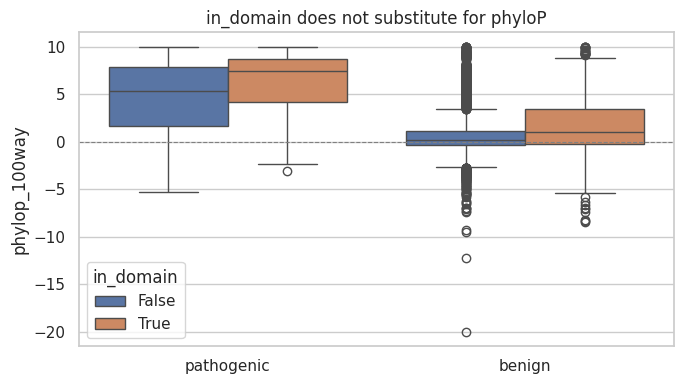

In [8]:
print("median phyloP by label × in_domain:")
print(
    model.groupby(["label", "in_domain"])["phylop_100way"]
    .median()
    .unstack()
    .rename(columns={False: "outside domain", True: "in domain"})
    .round(2)
    .to_string()
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(
    data=model.dropna(subset=["phylop_100way"]),
    x="label", y="phylop_100way", hue="in_domain", ax=ax,
)
ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.set_xlabel("")
ax.set_title("in_domain does not substitute for phyloP")
plt.tight_layout()
plt.show()


## 7. VUS sit in the middle

Held-out uncertain variants should look less like BA1-common benign and less like strongly conserved pathogenic — the region where PP3/BP4 would not have been decisive alone.


            count  median   mean
label                           
benign       5210   0.229  0.756
pathogenic   6352   5.938  5.307
vus          3506   5.087  4.810


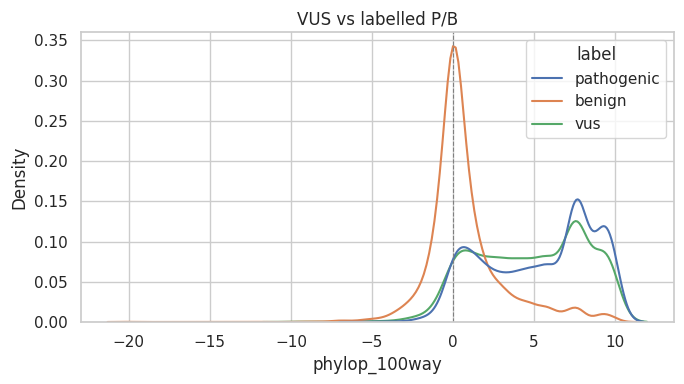

In [9]:
vus = prepare_inference_frame(pd.read_parquet(POSITION_MATCHED_VUS), labels={"vus"})
cmp = pd.concat(
    [
        model[["phylop_100way", "label"]],
        vus.assign(label="vus")[["phylop_100way", "label"]],
    ],
    ignore_index=True,
)
print(cmp.groupby("label")["phylop_100way"].agg(["count", "median", "mean"]).round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=cmp.dropna(subset=["phylop_100way"]), x="phylop_100way", hue="label", common_norm=False, ax=ax)
ax.axvline(0, color="grey", lw=0.8, ls="--")
ax.set_title("VUS vs labelled P/B")
plt.tight_layout()
plt.show()
